# Projeto reconhecimento de dígitos manuscritos

Etapas:

- Carregar dados
- Definir modelo Keras
- Compilar modelo Keras
- Ajustar (fit) modelo Keras
- Avaliar (evalute) modelo Keras
- Faça previsões (predict)

## Carregar dados

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
mnist = keras.datasets.mnist
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
mnist

<module 'keras.datasets.mnist' from '/opt/anaconda3/envs/machine_learning_tf/lib/python3.10/site-packages/keras/datasets/mnist/__init__.py'>

In [4]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [5]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [6]:
type(x_train[0])

numpy.ndarray

In [7]:
x_train.shape

(60000, 28, 28)

In [8]:
x_train[0][0].shape

(28,)

In [9]:
y_train.shape

(60000,)

In [10]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [11]:
import numpy as np

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [12]:
np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [13]:
contagem = tuple(zip(*np.unique(y_train, return_counts=True)))
contagem

((np.uint8(0), np.int64(5923)),
 (np.uint8(1), np.int64(6742)),
 (np.uint8(2), np.int64(5958)),
 (np.uint8(3), np.int64(6131)),
 (np.uint8(4), np.int64(5842)),
 (np.uint8(5), np.int64(5421)),
 (np.uint8(6), np.int64(5918)),
 (np.uint8(7), np.int64(6265)),
 (np.uint8(8), np.int64(5851)),
 (np.uint8(9), np.int64(5949)))

In [14]:
for par in contagem:
    print(f"{par[0]}: {par[1] / len(y_train) * 100:.2f}%")

0: 9.87%
1: 11.24%
2: 9.93%
3: 10.22%
4: 9.74%
5: 9.04%
6: 9.86%
7: 10.44%
8: 9.75%
9: 9.92%


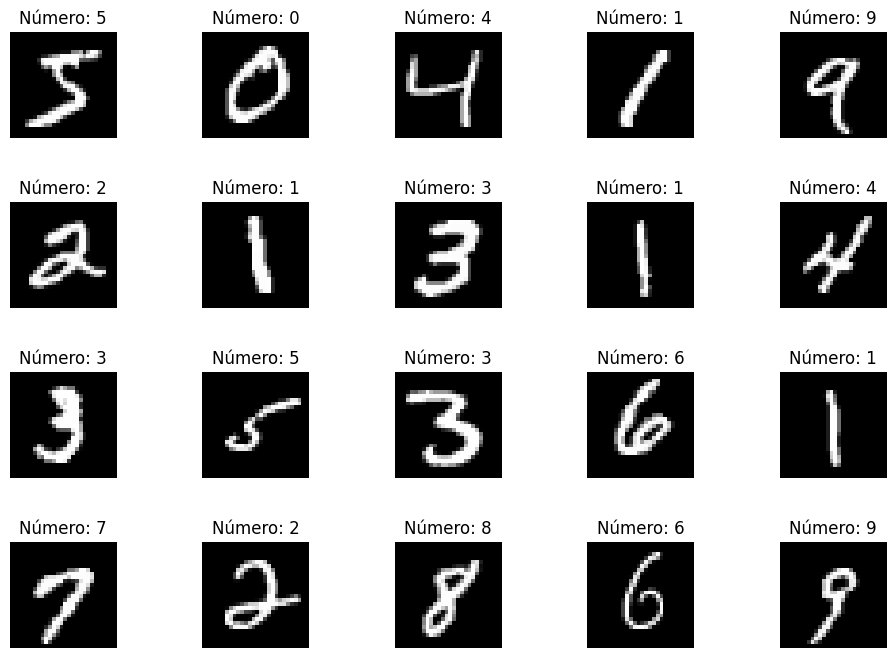

In [15]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i], cmap="gray")
    ax.set_title(f"Número: {y_train[i]}")
    ax.axis("off")

fig.subplots_adjust(hspace=0.6)

plt.show()

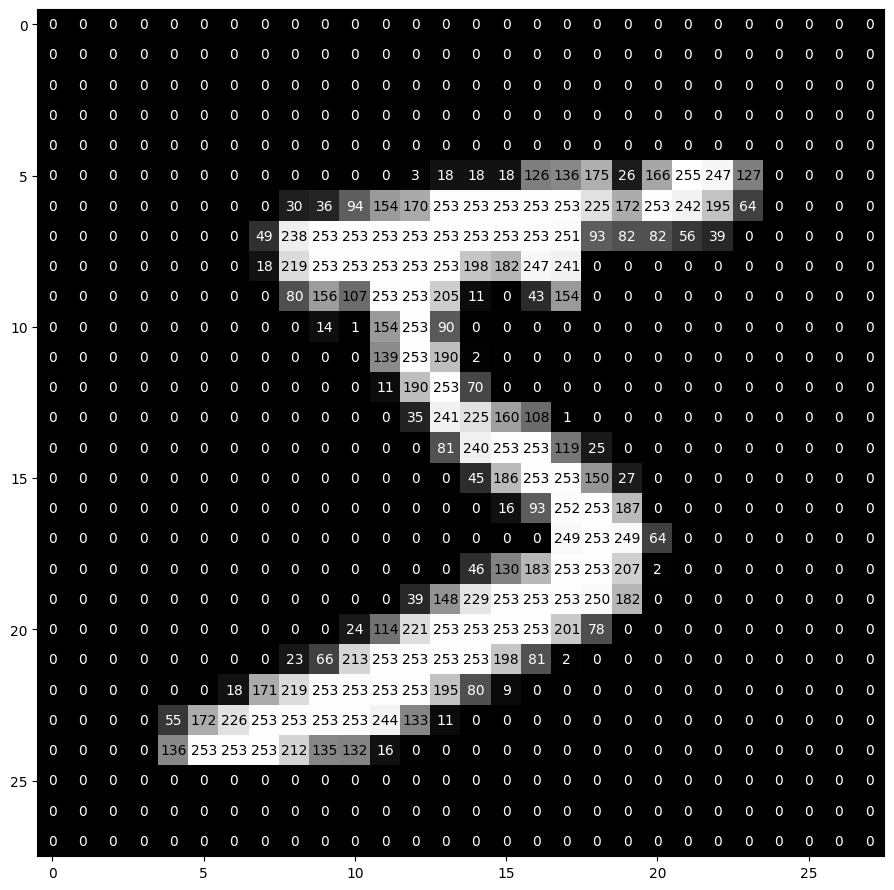

In [16]:
fig, ax = plt.subplots(figsize=(11, 11))

ax.imshow(x_train[0], cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna]
        ax.annotate(
            str(valor),
            xy=(coluna, linha),
            color="black" if valor > 100 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

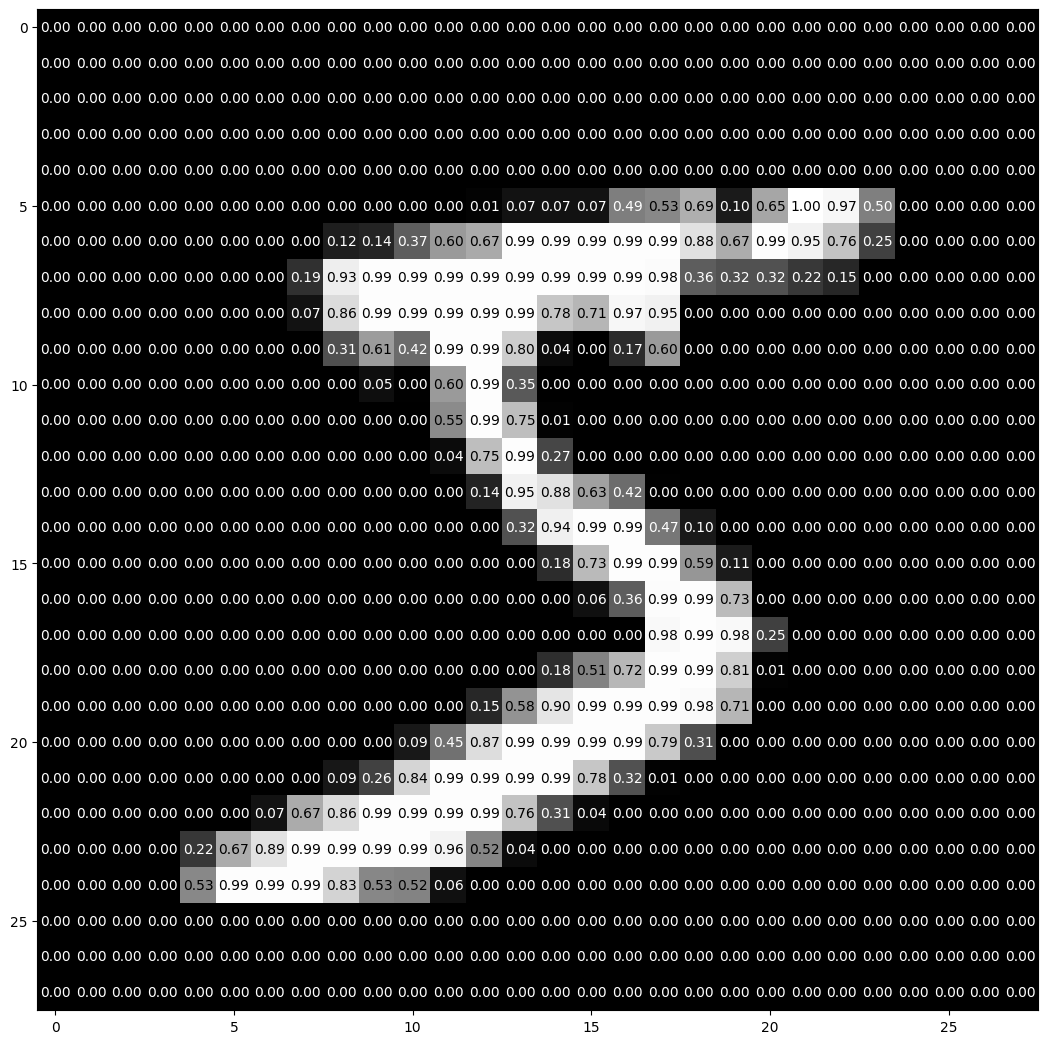

In [17]:
fig, ax = plt.subplots(figsize=(13, 13))

ax.imshow(x_train[0] / 255, cmap="gray")

for linha in range(28):
    for coluna in range(28):
        valor = x_train[0][linha][coluna] / 255
        ax.annotate(
            f"{valor:.2f}",
            xy=(coluna, linha),
            color="black" if valor > 0.5 else "white",
            horizontalalignment="center",
            verticalalignment="center",
        )

plt.show()

## Definir modelo Keras

https://www.tensorflow.org/guide/keras/preprocessing_layers

In [18]:
model = keras.models.Sequential()

model.add(keras.layers.InputLayer(shape=(28, 28, 1)))
model.add(keras.layers.Rescaling(scale=1./255))
model.add(keras.layers.RandomRotation(0.1))
model.add(keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1))
model.add(keras.layers.RandomZoom(0.1))
model.add(keras.layers.Conv2D(64, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Conv2D(128, (3, 3), activation="relu"))
model.add(keras.layers.MaxPooling2D())
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(10, activation="softmax"))

model.summary()

/opt/anaconda3/envs/machine_learning_tf/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 26, 26, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        32,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,506 (416.04 KB)

 Trainable params: 106,506 (416.04 KB)

 Non-trainable params: 0 (0.00 B)

## Compilar modelo Keras

In [19]:
optimizer = keras.optimizers.Adam(learning_rate=1E-3)
loss = keras.losses.SparseCategoricalCrossentropy()
metric = keras.metrics.SparseCategoricalAccuracy()

model.compile(optimizer=optimizer, loss=loss, metrics=[metric])

## Fit modelo Keras

In [20]:
early_stop = keras.callbacks.EarlyStopping(
    patience=5,
    verbose=1,
    min_delta=1E-4,
)

history = model.fit(
    x_train,
    y_train,
    epochs=300,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
)

Epoch 1/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 1.2113 - sparse_categorical_accuracy: 0.6076 - val_loss: 0.1804 - val_sparse_categorical_accuracy: 0.9503
Epoch 2/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 103ms/step - loss: 0.5329 - sparse_categorical_accuracy: 0.8317 - val_loss: 0.1484 - val_sparse_categorical_accuracy: 0.9554
Epoch 3/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.4163 - sparse_categorical_accuracy: 0.8702 - val_loss: 0.1123 - val_sparse_categorical_accuracy: 0.9681
Epoch 4/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.3566 - sparse_categorical_accuracy: 0.8911 - val_loss: 0.1117 - val_sparse_categorical_accuracy: 0.9685
Epoch 5/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 107ms/step - loss: 0.3067 - sparse_categorical_accuracy: 0.9074 - val_loss: 0.0849 - val_sparse_categorical_accuracy: 0.9763
Epoch 6/300
94/94 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - loss: 0.2777 - sparse_categorical_accuracy: 0.9154 - val_loss: 0.0819 - val_sparse_categorical_accuracy:

## Evaluate modelo Keras

In [22]:
model.save("model/model_best_hpsV1.keras")

In [24]:
loaded_model = keras.models.load_model("model/model_best_hpsV1.keras")

In [25]:
loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0409 - sparse_categorical_accuracy: 0.9872


[0.040884751826524734, 0.9872000217437744]

## Predict modelo Keras

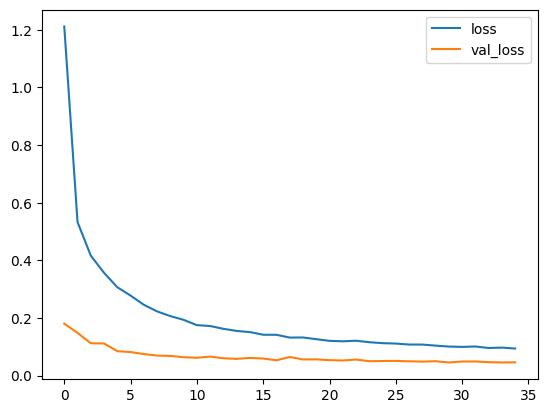

In [26]:
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()

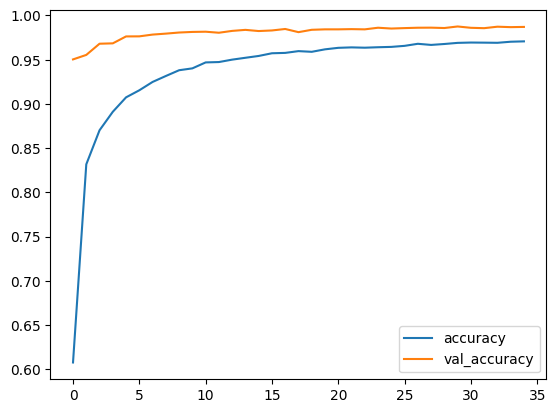

In [27]:
plt.plot(history.history["sparse_categorical_accuracy"], label="accuracy")
plt.plot(history.history["val_sparse_categorical_accuracy"], label="val_accuracy")
plt.legend()
plt.show()

In [28]:
x_test[0].shape

(28, 28)

In [29]:
np.expand_dims(x_test[0], axis=0).shape

(1, 28, 28)

In [30]:
model.predict(np.expand_dims(x_test[0], axis=0))[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


array([2.4274893e-08, 1.2406073e-07, 1.4360355e-03, 1.5681415e-05,
       1.7592432e-08, 2.1249431e-09, 3.2604507e-15, 9.9854362e-01,
       5.9396751e-07, 3.8845069e-06], dtype=float32)

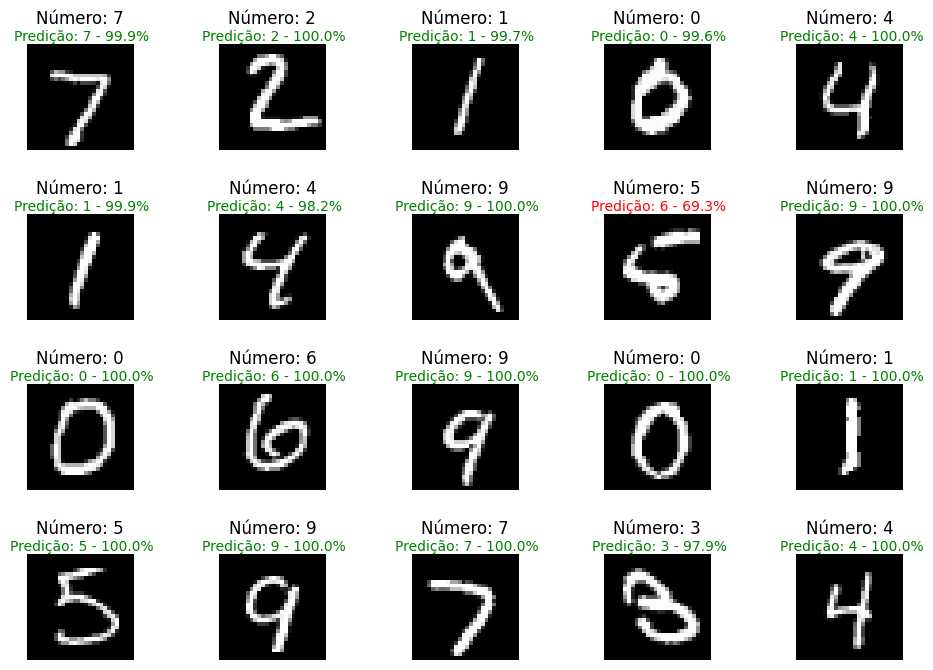

In [31]:
fig, axs = plt.subplots(4, 5, figsize=(12, 8))

for i, ax in enumerate(axs.flat):
    ax.imshow(x_test[i], cmap="gray")
    ax.set_title(f"Número: {y_test[i]}", pad=15)
    ax.axis("off")
    pred = model.predict(np.expand_dims(x_test[i], axis=0), verbose=0)[0]
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if pred.argmax() == y_test[i] else "red",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

https://www.tensorflow.org/api_docs/python/tf/keras/utils/load_img

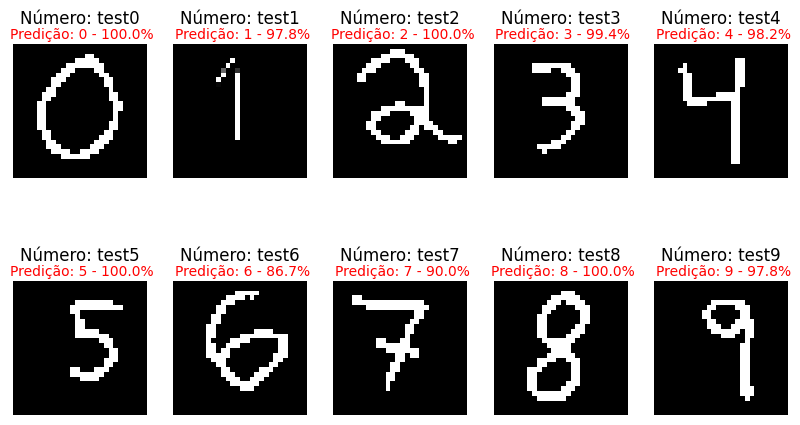

In [32]:
test_images_dir = Path("imagensTeste")

fig, axs = plt.subplots(2, 5, figsize=(10, 5))

all_pred = {}

for i, (img, ax) in enumerate(zip(sorted(test_images_dir.glob("*.png")), axs.flat)):
    
    name = img.name.split(".")[0]
    
    img = keras.preprocessing.image.load_img(
        img, target_size=(28, 28), color_mode="grayscale"
    )
    img_array = keras.preprocessing.image.img_to_array(img)
    img_array = 255 - img_array
    img_array = tf.expand_dims(img_array, 0)
    
    pred = model.predict(img_array, verbose=0)
    all_pred[name] = pred

    ax.imshow(img_array[0], cmap="gray")
    ax.set_title(f"Número: {name}", pad=15)
    ax.axis("off")
    ax.text(
        14,
        -2.5,
        f"Predição: {pred.argmax()} - {pred.max():.1%}",
        color="green" if str(pred.argmax()) == name else "red",
        verticalalignment="center",
        horizontalalignment="center",
    )

fig.subplots_adjust(hspace=0.6)

plt.show()

In [33]:
all_pred["test5"]

array([[1.7266103e-08, 3.0587019e-16, 1.0265082e-09, 1.6708858e-04,
        3.6642238e-16, 9.9981946e-01, 6.8599502e-07, 2.6555911e-09,
        1.2406569e-05, 4.0584405e-07]], dtype=float32)

In [34]:
all_pred["test6"]

array([[5.9806189e-05, 2.3053598e-22, 4.1513735e-09, 2.5003036e-10,
        1.0182963e-10, 1.2670277e-01, 8.6720002e-01, 5.1637183e-13,
        6.0133985e-03, 2.3998302e-05]], dtype=float32)

In [35]:
all_pred["test7"]

array([[1.4978965e-15, 3.7611643e-13, 3.3186201e-04, 9.9773660e-02,
        3.2894193e-12, 3.8949607e-11, 3.2944359e-16, 8.9989358e-01,
        8.1969756e-07, 3.9998636e-08]], dtype=float32)